In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

In [2]:
from google.colab import files
uploaded = files.upload()

Saving final_air_quality_dataset (1).csv to final_air_quality_dataset (1).csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(list(uploaded.keys())[0])

# Clean column names
df.columns = df.columns.str.strip().str.lower()

df.head()

,pm2.5,pm10,no2,co,so2,o3,aqi
0,54.145833,114.449583,18.22,0.92,27.64,133.36,128.416667
1,54.145833,114.449583,15.69,0.97,24.55,34.06,128.416667
2,54.145833,114.449583,19.30,17.40,29.07,30.70,128.416667
3,54.145833,114.449583,18.48,1.70,18.59,36.08,128.416667
4,54.145833,114.449583,21.42,22.10,39.33,39.31,128.416667


In [5]:
# Remove unwanted columns
df = df.drop(columns=["city", "date", "aqi_category", "country", "region"], errors="ignore")

# Keep numeric columns
df = df.select_dtypes(include=[np.number])

# Fill missing values
df = df.fillna(df.median())

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274559 entries, 0 to 274558
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   pm2.5   274559 non-null  float64
 1   pm10    274559 non-null  float64
 2   no2     274559 non-null  float64
 3   co      274559 non-null  float64
 4   so2     274559 non-null  float64
 5   o3      274559 non-null  float64
 6   aqi     274559 non-null  float64
dtypes: float64(7)
memory usage: 14.7 MB


In [6]:
df["pollution_sum"] = df[["pm2.5","pm10","no2","so2","co","o3"]].sum(axis=1)
df["pollution_mean"] = df[["pm2.5","pm10","no2","so2","co","o3"]].mean(axis=1)

df["pm_ratio"] = df["pm2.5"] / (df["pm10"] + 1)
df["gas_ratio"] = df["no2"] / (df["so2"] + 1)

df["pm_interaction"] = df["pm2.5"] * df["pm10"]
df["gas_interaction"] = df["no2"] * df["co"]
df["pollution_index"] = df["pm2.5"] * 0.5 + df["pm10"] * 0.3 + df["no2"] * 0.2

In [7]:
X = df[[
    "pm2.5","pm10","no2","so2","co","o3",
    "pollution_sum","pollution_mean","pm_ratio","gas_ratio"
]]

y = df["aqi"]

In [8]:
X = X.clip(lower=X.quantile(0.01), upper=X.quantile(0.99), axis=1)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=1800,
    learning_rate=0.02,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.3,
    reg_lambda=2,
    gamma=0.1,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1800,
             n_jobs=None, num_parallel_tree=None, ...)

In [11]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Model Accuracy (R2 Score): {r2*100:.2f}%")
print(f"RMSE: {rmse:.2f}")

Model Accuracy (R2 Score): 94.65%
RMSE: 28.16


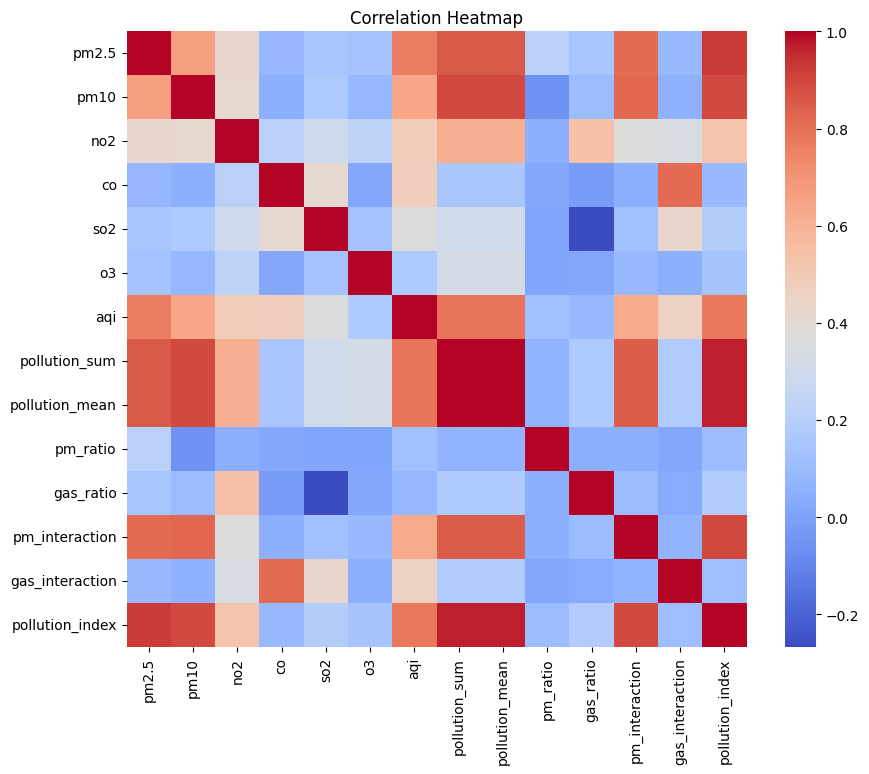

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

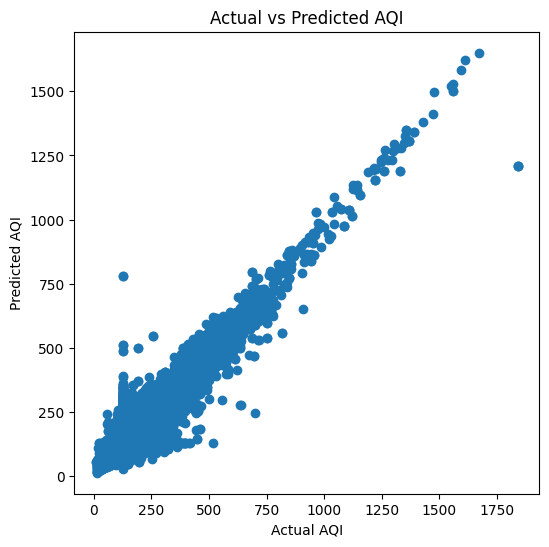

In [13]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.show()

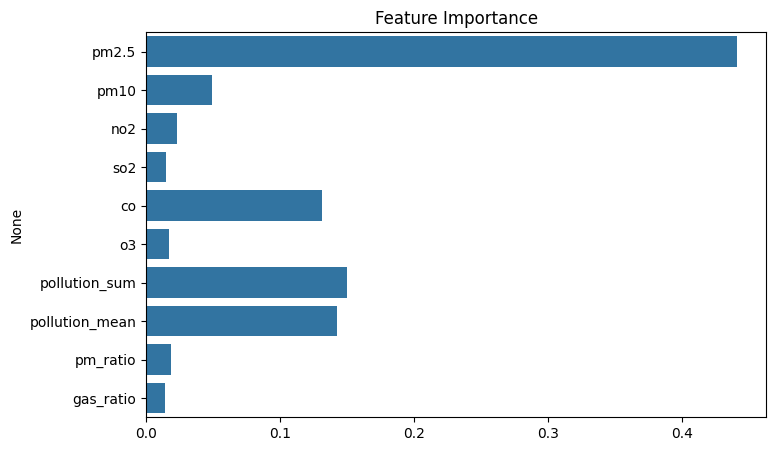

In [14]:
importances = model.feature_importances_

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=X.columns)
plt.title("Feature Importance")
plt.show()

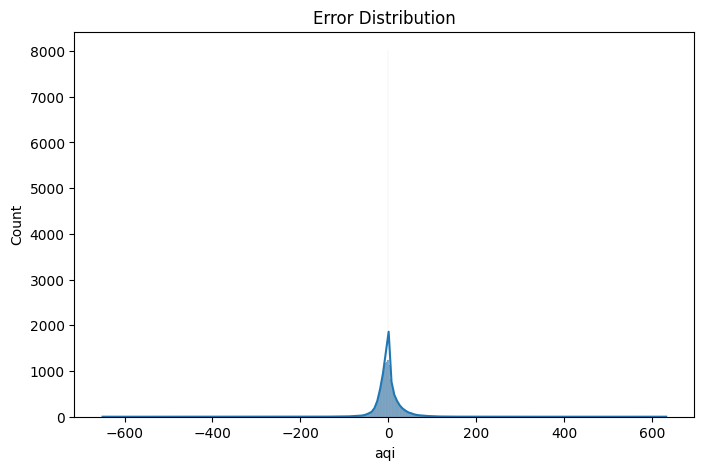

In [15]:
errors = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(errors, kde=True)
plt.title("Error Distribution")
plt.show()

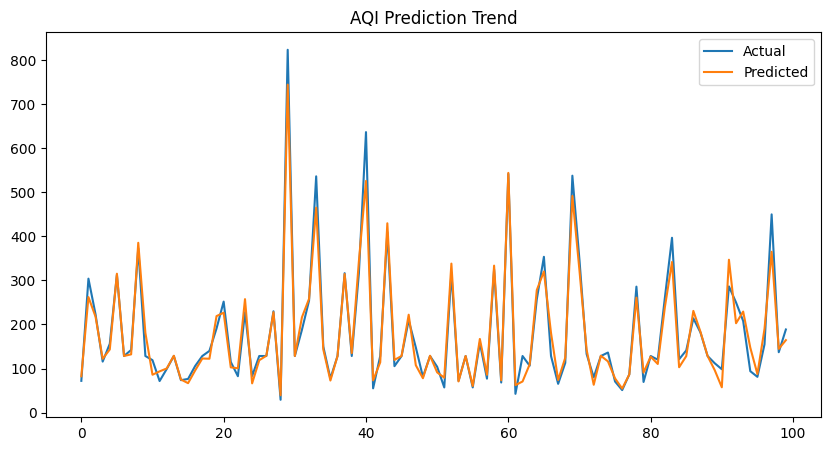

In [16]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.legend()
plt.title("AQI Prediction Trend")
plt.show()